# **Análise exploratória de dados**
<font size=3>

A Análise Exploratória de Dados (AED) é uma etapa fundamental em qualquer projeto de Aprendizado de Máquina ou Ciência de Dados, pois permite compreender melhor a estrutura e as características do conjunto de dados antes da aplicação de algoritmos. Nessa fase, o objetivo é identificar padrões, relações e tendências, bem como detectar possíveis inconsistências, outliers ou valores ausentes. Para isso, utilizam-se medidas estatísticas descritivas (como média, variância, covariância e correlação) e técnicas de visualização (como histogramas, gráficos de dispersão e matrizes de correlação), que oferecem uma visão inicial sobre a distribuição e a interação entre as variáveis. Essa compreensão preliminar orienta a escolha de métodos de pré-processamento e modelos de aprendizado mais adequados, tornando a AED uma etapa indispensável para análises confiáveis e resultados robustos.

## __1. O conjunto de dados:__
<font size=3>

Na aula passada, vimos que os conjuntos de dados (_dataset_) frequentemente trabalhados em Aprendizado de Máquina são formados por <span style="color:darkred">amostras</span> e <span style="color:darkred">atributos</span>. Como exemplo, apresentamos os dados de flores de íris.

In [ ]:
# Para habilitar o Colab a acessar o Drive, siga os passos do notebook "importar_no_colab.ipynb".

from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [11]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/1-unidade')


In [12]:
from toolbox import dataset_iris

df_iris = dataset_iris()
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
26,5.0,3.4,1.6,0.4,setosa
45,4.8,3.0,1.4,0.3,setosa
85,6.0,3.4,4.5,1.6,versicolor
132,6.4,2.8,5.6,2.2,virginica
27,5.2,3.5,1.5,0.2,setosa


<font size=3>

Matematicamente, podemos definir o <span style="color:darkgreen">conjunto de dados</span> como $\textbf{x} \in \mathbb{R}^{n,\,d}$, onde $n$ é o número de amostras e $d$ é o número de atributos. Assim, chamamos $x_{ij}$ o <span style="color:darkblue">valor de atributo</span> da linha $i$ e coluna $j$.

<font size=3>

Estes valores de atributos podem ser do tipo <span style="color:darkred">numérico</span> (inteiros, racionais) ou <span style="color:darkgreen">categórico</span> (_strings_, _booleano_). Abaixo, exemplos em **Python**:

In [13]:
numero_de_petalas = 4
print(type(numero_de_petalas))

comprimento_medio_petala = 3.6
print(type(comprimento_medio_petala))

especie = "virginica"
print(type(especie))

colhida_hoje = True
print(type(colhida_hoje))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


## __2. Exploração de dados:__
<font size=3>

Uma exploração básica dos dados requer <span style="color:darkgreen">análise descritiva</span> a fim de extrair informações: **frequência**, **tendência central**, **dispersão** e **distribuição**. Chamamos de <span style="color:darkblue">dados univariados</span> aqueles com apenas um atributo ($x_i$); e <span style="color:darkred">dados multivariados</span> quando contêm mais de um atributo ($x_{ij}$).

### __2.1 Dados univariados:__
<font size=3>

Para ilustrar nosso estudo, considere a seguinte **_lista_** de amostras $x_i$ de atributo <span style="color:darkred">_discreto_</span> (podendo ser também variáveis _booleanas_ ou _strings_).
A **moda** de um conjunto de dados é o valor que ocorre com maior frequência, dado por
$$
   M_o(x) = \arg\max_{x} f(x) \, ,
$$
onde $f(x)$ representa a frequência dos valores $x$.

In [14]:
def Moda(x):

    freq = {} # dicionário python

    for valor in x:

        if valor in freq:
            freq[valor] += 1

        else: # definindo ao valor a quantidade 1
            freq[valor] = 1

    moda = max(freq, key=freq.get)

    return moda, freq


x = ['a', 'b', 'b', 'c', 'd', 'd', 'd', 'e', 'e']

moda, freq = Moda(x)

print("Frequência =", freq)
print("Moda =", moda)

Frequência = {'a': 1, 'b': 2, 'c': 1, 'd': 3, 'e': 2}
Moda = d


#### __2.1.1 Medidas de tendência central:__
<font size=3>

Considerando, agora, amostras $x_i$ de atributo <span style="color:darkred">_numérico_</span> do conjunto de dados de flores de íris:

In [15]:
# acessando o atributo "comprimento das pétalas" do dataframe e transformando em lista:
x = df_iris['petal length (cm)'].to_list()

n = len(x)

print("Esse conjunto de dados univariado é de comprimento:", n)
print(f"Assim, para x_i, i = [1, 2, 3, ..., {n}].")

Esse conjunto de dados univariado é de comprimento: 150
Assim, para x_i, i = [1, 2, 3, ..., 150].


<font size=3>
    
A **média** aritmética ($\bar x$) de um conjunto de dados é dada por,
$$
   \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \, .
$$

Os valores <span style="color:darkblue">_outliers_</span> são observações que se diferenciam significativamente do restante dos dados, podendo ser muito maiores ou muito menores do que a maioria dos valores. Eles podem ocorrer devido a erros de medição, variabilidade natural dos dados ou eventos excepcionais.

A média é altamente sensível a _outliers_, pois valores extremos influenciam diretamente o somatório, deslocando a média na direção dos _outliers_.

In [16]:
def Media(x):

    n = len(x)

    return sum(x)/n

print(f"Média de x = {Media(x):.3f}")

Média de x = 3.758


<font size=3>
    
A **mediana** ($\tilde x$) é o valor central de um conjunto de dados ordenado. Formalmente:


\begin{align}
    \tilde x &=
    \begin{bmatrix}
        \dfrac12 \left(x_{n/2} + x_{n/2+1}\right) \, ,\quad n \; \text{par} \\
        x_{n/2} \, ,\quad n \; \text{ímpar}
     \end{bmatrix} \, .
\end{align}
A mediana é robusta a _outliers_, pois depende apenas da posição dos valores e não de sua magnitude.

In [17]:
def Mediana(x):

    n = len(x)
    x = sorted(x) # ordenando os dados

    if n%2 == 0: # n par
        return 0.5*(x[n//2 - 1] + x[n//2])

    else: # n ímpar
        return x[n//2]

print(f"Mediana de x = {Mediana(x):.3f}")

Mediana de x = 4.350


<font size=3>
    
O **percentil** indica o valor abaixo do qual uma determinada porcentagem dos dados está contida. Por exemplo, o percentil $p=10$ representa o valor abaixo do qual estão 10% dos menores valores do conjunto. Os percentis 25%, 50% e 75% são conhecidos como *1º quartil*, *2º quartil (mediana)* e *3º quartil*, respectivamente. Enquanto percentis próximos às extremidades (como o 1º ou 99º percentil) são mais sensíveis a outliers, valores centrais (como o 2º quartil) são mais robustos (menos sensível a variações extremas) e menos afetados por valores extremos.

Para calcular, precisamos:
 - Ordenar os dados em ordem crescente;
 - A posição do percentil é calculada com base no tamanho do conjunto de dados e no percentil desejado;
 - Se a posição não for inteira, é feita uma [interpolação linear](https://pt.wikipedia.org/wiki/Interpola%C3%A7%C3%A3o_linear#:~:text=Na%20matem%C3%A1tica%2C%20Interpola%C3%A7%C3%A3o%20linear%20%C3%A9,alcance%20de%20pontos%20j%C3%A1%20conhecidos.) entre os dois valores mais próximos.


In [18]:
def Percentil(x, p):

    n = len(x)
    x = sorted(x) # ordenando os dados

    posicao = p*(n - 1) # posição do percentil p

    if posicao.is_integer(): # se o valor da posição é inteiro
        return x[int(posicao)]

    else: # Se fracionária, faz interpolação linear entre os dois valores mais próximos
        pos_inferior = int(posicao)
        pos_superior = pos_inferior + 1

        valor_inferior = x[pos_inferior]
        valor_superior = x[pos_superior]

        fracao = posicao - pos_inferior

        return valor_inferior + (valor_superior - valor_inferior)*fracao

p = 0.75 # (terceiro quartil)
print(f"p {100*p}%: {Percentil(x, p)}")

p 75.0%: 5.1


<font size=3>

O **boxplot** (ou diagrama de caixa) é um gráfico estatístico que resume a distribuição de um conjunto de dados por meio de cinco números principais: mínimo, 1º quartil (Q1), 2º quartil (Q2), 3º quartil (Q3) e máximo.
 - A caixa representa a dispersão dos dados entre Q1 e Q3 (50% dos dados centrais);  
 - A linha dentro da caixa indica a mediana (Q2);  
 - Os "bigodes" são as linhas verticais que se estendem até os valores mínimo e máximo.
  

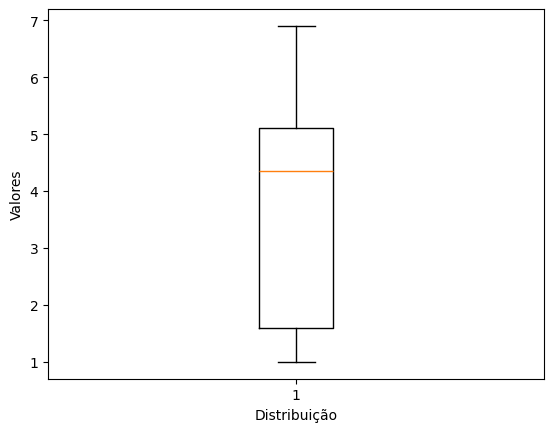

In [19]:
import matplotlib.pyplot as plt

plt.boxplot(x)
plt.xlabel('Distribuição')
plt.ylabel('Valores')
plt.show()

#### __2.1.2 Medidas de dispersão:__
<font size=3>

As **medidas de espalhamento** na estatística descritiva avaliam a dispersão dos dados em torno de uma medida central, como a média ou mediana. A seguir, as principais formas de medida.

O **intervalo** (amplitude) é a diferença entre o maior e o menor valor do conjunto de dados.
$$
    \Delta x = \max(x) - \min(x) \, .
$$
Como o intervalo depende apenas dos valores máximo e mínimo, um único <span style="color:blue">_outlier_</span> pode <span style="color:darkred">aumentar drasticamente</span> sua magnitude, subestimando a dispersão real da maioria dos dados.

In [20]:
def Intervalo(x):
    return max(x) - min(x)


print(f"Δx =", Intervalo(x))

Δx = 5.9


<font size=3>

A **variância** ($s^2$) é a média dos quadrados dos desvios em relação à média $\bar x$ da amostra,
$$
    s^2(x) = \frac{1}{n-1} \sum_{i=1}^n (x_i - \bar x)^2 \, ,
$$
onde o denominador $(n-1)$ é a <span style="color:darkgreen">correção de Bessel</span> usada para corrigir o viés estatístico da estimativa quando usado parte de uma <span style="color:darkblue">população</span> (_i.e._, uma *amostragem*). Quando calculamos a totalidade dos dados (a população total), a variância é dada por,
$$
    \sigma^2(x) = \frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2 \, ,
$$
onde $\mu$ é a média da população.

In [21]:
def Variancia(x):

    n = len(x)
    mu = Media(x)

    dif_quadratica = [] # definindo lista

    for x_i in x:
        dif_quadratica.append((x_i - mu)**2)

    return (1/n)*sum(dif_quadratica)


print(f"σ^2(x) = {Variancia(x):.3f}")

σ^2(x) = 3.096


<font size=3>

Falando-se de variância, o **desvio padrão** ($\sigma$ ou $s$) é a raiz quadrada da variância,
\begin{align}
    \sigma(x) &= \sqrt{\sigma^2(x)} \, ,\\
    s(x) &= \sqrt{s^2(x)} \, .
\end{align}

Como ambas as medidas dependem dos *quadrados dos desvios* em relação à média, _outliers_ *aumentam significativamente* sua magnitude. Logo, a variância é mais afetada por ser uma medida quadrática.  

In [22]:
def Desvio_Padrao(x):
    return Variancia(x)**0.5


print(f"σ(x) = {Desvio_Padrao(x):.3f}")

σ(x) = 1.759


<font size=3>

Para uma análise mais robusta de medidas de dispersão, temos o **Desvio Médio Absoluto** (_absolute average deviation_ &mdash; AAD) que mensura a dispersão média dos dados em relação à *média*, usando valores absolutos para evitar cancelamento de desvios positivos e negativos.
$$
\text{AAD}(x) = \frac{1}{n} \sum_{i=1}^n |x_i - \bar{x}|
$$  

In [23]:
def AAD(x):

    n = len(x)
    mu = Media(x)

    dif_abs = [] # definindo lista

    for x_i in x:
        dif_abs.append(abs(x_i - mu))

    return (1/n)*sum(dif_abs)


print(f"AAD(x) = {AAD(x):.3f}")

AAD(x) = 1.563


<font size=3>
    
Já o **Desvio Mediano Absoluto** (_median absolute deviation_ &mdash; MAD) considera a _mediana_ dos dados, dado como
$$
    \text{MAD}(x) = \text{Mediana}\left(|x_i - \text{Mediana}(x)|\right) \, ,
$$  
é robusto a outliers, já que depende apenas da mediana &mdash; que ignora valores extremos.

In [24]:
def MAD(x):

    med = Mediana(x)

    dif_med = [] # definindo lista

    for x_i in x:
        dif_med.append(abs(x_i - med))

    return Mediana(dif_med)


print(f"MAD(x) = {MAD(x):.3f}")

MAD(x) = 1.250


<font size=3>

Também temos a medida de **Intervalo Interquartil** (_interquartil range_ &mdash; IQG) que mede a dispersão do _50% central_ dos dados &mdash; entre o 3º quartil ($Q_3$) e o 1º quartil ($Q_1$).
$$
\text{IQR}(x) = Q_3(x) - Q_1(x) = p_{75}(x) - p_{25}(x)\, .
$$
Esta medida elimina a influência dos 25% menores e 25% maiores valores, sendo ideal para análise de dados com outliers.

In [25]:
def IQR(x):

    Q1 = Percentil(x, 0.25) # 1º quartil
    Q3 = Percentil(x, 0.75) # 3º quartil

    return Q3 - Q1

print(f"IQR(x) = {IQR(x):.3f}")

IQR(x) = 3.500


<font size=3>
    
**Em resumo**, as métricas de dispersão podem sugerir que os dados são mais heterogêneos do que realmente são.
 - No caso de *distribuições assimétricas* ou com caudas longas, **variância** e **desvio padrão** perdem utilidade descritiva;
 - Prefira **MAD** ou **IQR** se houver outliers ou assimetria;
 - Use **AAD** para uma alternativa mais simples ao desvio padrão, mas ainda sensível a extremos.


#### __2.1.3 Medidas de distribuição:__
<font size=3>

Uma maneira de se visualizar a forma da **distribuição** de um conjunto de dados é através de um **histograma**, que se trata de um gráfico de barras que representa a distribuição de frequências de um conjunto de dados contínuos, dividindo-os em intervalos (chamados de "_bins_" ou _classes_). Cada barra corresponde a uma faixa de valores, e sua altura indica a quantidade ou a frequência de observações dentro desse intervalo.

Este gráfico permite visualizar a forma da distribuição (como simetria, assimetria, modas e dispersão), identificar tendências centrais (como média e mediana) e detectar _outliers_ ou outros padrões nos dados.

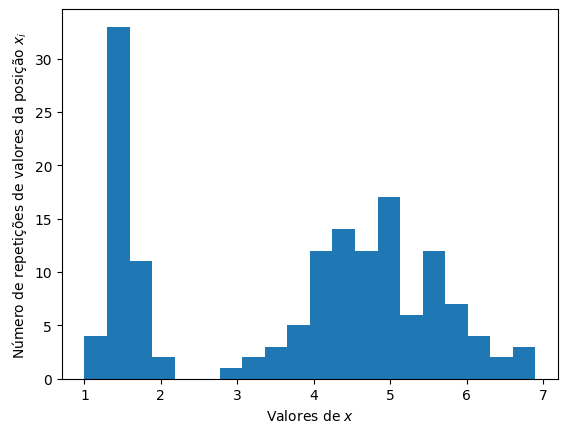

In [26]:
plt.hist(x, bins=20)
plt.ylabel("Número de repetições de valores da posição $x_i$")
plt.xlabel("Valores de $x$")
plt.show()

<font size=3>

Para formular matematicamente a leitura de um histograma, descreveremos de maneira generalista uma medida em torno da média, chamada **momento**,
$$
    \text{Momento}_k(x) = \frac{1}{n-1}\sum_{i=1}^n \left(x_i - \bar x\right)^k \, .
$$
Quando $k=1$, temos o **valor 0** (uma medida de dispersão); para $k=2$ temos a **variância** ($s^2$) de uma amostra.

In [27]:
def Momento(x, k):

    n = len(x)
    x_bar = Media(x)

    dif = []

    for x_i in x:
        dif.append((x_i - x_bar)**k)

    return sum(dif)/(n - 1)


def Var_s(x): # s^2: para uma amostra

    n = len(x)
    mu = Media(x)

    dif_quadratica = []

    for x_i in x:
        dif_quadratica.append((x_i - mu)**2)

    return sum(dif_quadratica)/(n - 1)

print(f"Momento_2(x) = {Momento(x, 2):.3f}.")
print(f"Variância(x) = {Var_s(x):.3f}.")

Momento_2(x) = 3.116.
Variância(x) = 3.116.


<font size=3>
    
Para $k=3$, temos a **obliquidade** que mede a simetria da distribuição/histograma. Sua forma matemática leva uma _normalização_ dada por $s^3$,
$$
    \text{Obliquidade}(x) = \frac{\text{Momento}_3(x)}{s^3} \, .
$$

- $\text{Obliquidade}(x) = 0$: a distribuição é simétrica;
- $\text{Obliquidade}(x) > 0$: a distribuição concentra-se do lado _esquerdo_ do histograma;
- $\text{Obliquidade}(x) < 0$: a distribuição concentra-se do lado _direito_ do histograma.


In [28]:
def Std_s(x): # s: para uma amostra
    return Var_s(x)**0.5


def Obliquidade(x):
    return Momento(x, 3)/Std_s(x)**3


print(f"Obliquidade(x) = {Obliquidade(x):.3f}.")

Obliquidade(x) = -0.271.


<font size=3>

O quarto momento, $k=4$, chamado **curtose** indica o achatamento de uma distribuição quando calculamos
$$
    \text{Curtose}(x) = \frac{\text{Momento}_4(x)}{s^4} \, .
$$

- $\text{Curtose}(x) = 0$: distribuição normal (_Gaussiana_);
- $\text{Curtose}(x) > 0$: distribuição mais alongada do que a normal;
- $\text{Curtose}(x) < 0$: distribuição mais achatada  do que a normal.


In [29]:
def Curtose(x):
    return Momento(x, 4)/Var_s(x)**4


print(f"Curtose(x) = {Curtose(x):.3f}.")

Curtose(x) = 0.164.


### __2.2 Dados multivariados:__
<font size=3>

Os dados das flores de íris são exemplo de dados **multivariados**. Quando desejamos conhecer a tendência central do conjunto de dados $\textbf{x} \in \mathbb{R}^{n,\,d}$, realizamos medidas por atributo, _e.g._
$$
    \mathbf{\bar x} = \left(\bar x^1, \bar x^2, \dots, \bar x^d\right) \, .
$$

Para correlacionar diferentes atributos em uma única análise, podemos considerar a dispersão entre dois atributos $x^i$ (_e.g._ comprimento da pétala) e $x^j$ (_e.g._ comprimento da sépala) dada pela **covariância**,
$$
    \text{Cov}\left(x^i,\, x^j\right) = \frac{1}{n - 1}\sum_{k=1}^n \left(x_k^i - \bar x^i\right)\left(x_k^j - \bar x^j\right) \, .
$$
Em uma **matriz de covariância**, cada elemento representa a covariância entre duas variáveis, indicando a direção (positiva ou negativa) e a intensidade de sua relação. Uma **covariância positiva** sugere que as variáveis tendem a aumentar ou diminuir juntas (**diretamente proporcionais**), enquanto uma **negativa** indica que uma aumenta quando a outra diminui (**inversamente proporcionais**).

Além disso, os elementos da diagonal representam as variâncias individuais de cada variável, $\text{Cov}(x^i, x^i) = \text{Variância}(x^i)$, refletindo sua dispersão.

In [30]:
# Considerando agora dois atributos dos dados de íris:
xi = df_iris['petal length (cm)'].to_list()
xj = df_iris['sepal length (cm)'].to_list()

In [31]:
def Cov(xi, xj):

    n = len(xi)

    xi_bar = Media(xi)
    xj_bar = Media(xj)

    dif = []
    for k in range(n):
        dif.append((xi[k] - xi_bar)*(xj[k] - xj_bar))

    return sum(dif)/(n - 1)


def matriz_cov(xi, xj): # considerando dois atributos

    cov_xi_xi = Cov(xi, xi)  # Variância de xi
    cov_xi_xj = Cov(xi, xj)  # Covariância entre xi e xj
    cov_xj_xi = Cov(xj, xi)  # Covariância entre xj e xi (simétrica)
    cov_xj_xj = Cov(xj, xj)  # Variância de xj

    return [[cov_xi_xi, cov_xi_xj],
            [cov_xj_xi, cov_xj_xj]]

matriz_cov(xi, xj)

[[3.1162778523489933, 1.274315436241611],
 [1.274315436241611, 0.6856935123042506]]

<font size=3>

Enquanto a covariância depende das escalas das variáveis (dificultando comparações), podemos utilizar a **correlação** como medida adimensional. Ela indica não apenas a direção (positiva/negativa) da relação, mas também sua *intensidade de forma interpretável* (_e.g_. 0.9 = forte relação linear, 0.2 = fraca) &mdash; o que facilita a comparação entre diferentes pares de variáveis e a identificação de padrões em análises estatísticas.
$$
    \text{Correlação}(x) = \frac{\text{Cov}(x^i,\, x^j)}{s^i\,s^j} \, .
$$

A correlação padroniza a medida de relação entre variáveis em uma escala universal entre $[-1,\, 1]$, independentemente das unidades ou da magnitude dos dados.


In [32]:
def Correlacao(xi, xj):

    si = Std_s(xi)
    sj = Std_s(xj)

    return Cov(xi, xj)/(sj*si)


print(f"Covariância(xi, xj) = {Cov(xi, xj):.3f}")
print(f"Correlação(xi, xj) = {Correlacao(xi, xj):.3f}")
print(f"Correlação(xi, xi) = {Correlacao(xi, xi):.3f}")

Covariância(xi, xj) = 1.274
Correlação(xi, xj) = 0.872
Correlação(xi, xi) = 1.000


<font size=3>

Como forma de visualização de dados multivariados, o **scatter plot** (gráfico de dispersão) pode ser utilizado para avaliar a capacidade de dois atributos discriminarem essas classes. Se a maioria dos objetos de cada classe puder ser separada por uma reta, isso indica que esses atributos possuem um bom poder de distinção entre as categorias.

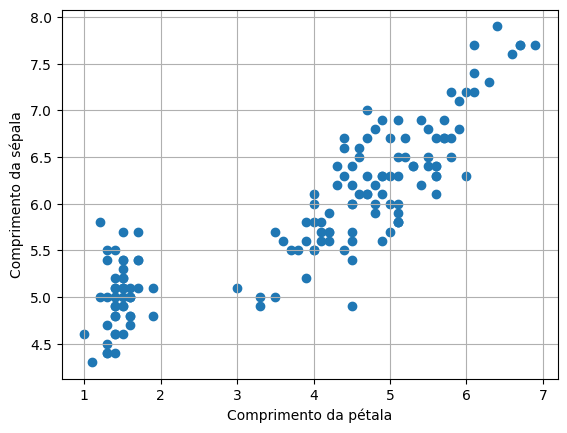

In [33]:
plt.scatter(xi, xj)
plt.ylabel("Comprimento da sépala")
plt.xlabel("Comprimento da pétala")
plt.grid()
plt.show()

<font size=3>
<br>
    
Até agora, visualizamos a dispersão de apenas duas variáveis por vez. No entanto, para conjuntos de dados com muitos atributos, é útil visualizar a correlação entre **todos os pares possíveis** de uma só vez. Abaixo, temos o **_pair plot_**, onde na diagonal principal, mantemos os histogramas (para ver a distribuição individual de cada atributo) e, fora da diagonal, plotamos os gráficos de dispersão coloridos pela espécie da flor. Note como essa visualização nos permite identificar rapidamente quais pares de atributos separam melhor as classes de íris.

In [34]:
from toolbox import plot_iris_correlacao

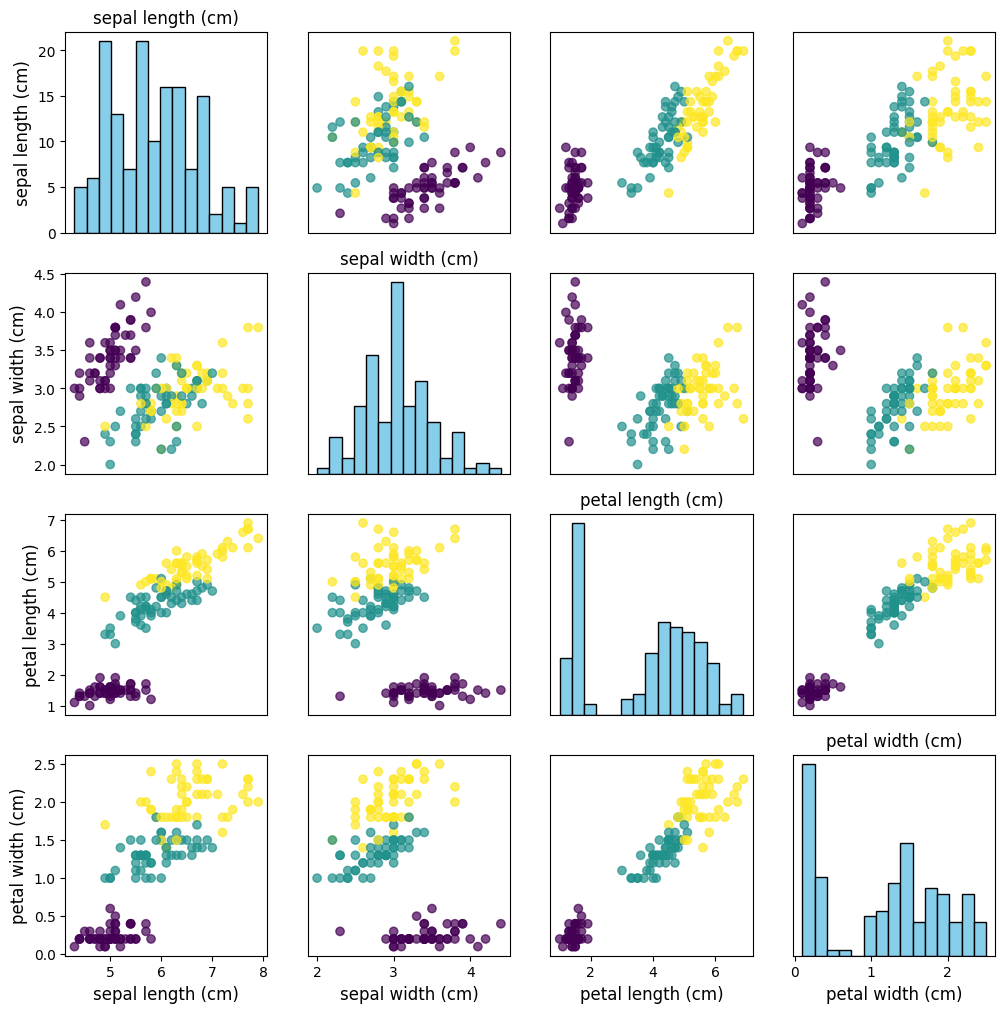

In [35]:
plot_iris_correlacao()

## __Referências:__
<font size=3>

- **(2.1 - 2.3)**: K. Faceli, Inteligência artificial: uma abordagem de aprendizado de máquina. Grupo Gen - LTC, 2011.
  